Importação das libs:

In [2]:
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from sklearn.model_selection import cross_val_score
import torchvision.transforms as transforms
from skorch import NeuralNetClassifier

Formação da base de dados:

In [3]:
torch.manual_seed(123)
transform = transforms.ToTensor()
train = datasets.MNIST(root = '.', train = True, download=True, transform=transform)

Construção do modelo:

In [4]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [5]:
class classificador_torch(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3,3))
    self.conv2 = nn.Conv2d(32, 32, (3, 3))
    self.activation = nn.ReLU()
    self.bnorm = nn.BatchNorm2d(num_features=32)
    self.pool = nn.MaxPool2d(kernel_size = (2,2))
    self.flatten = nn.Flatten()

    self.linear1 = nn.Linear(in_features=32*5*5, out_features=128)
    self.linear2 = nn.Linear(128, 128)
    self.output = nn.Linear(128, 10)
    self.dropout = nn.Dropout(p = 0.2)

    self.model = nn.Sequential(
      self.conv1,
      self.activation,
      self.bnorm,
      self.pool,

      self.conv2,
      self.activation,
      self.bnorm,
      self.pool,

      self.flatten,

      self.linear1,
      self.activation,
      self.dropout,

      self.linear2,
      self.activation,
      self.dropout,

      self.output
    ).to(device)

  def forward(self, X):
    # Tem que transformar as imagens no formato que as CNNs operam no PyTorch: (batch_number, n_channels, height, width)
    # Isso precisa ser feito nesse notebook, e não no classificador_digitos_manuscritos.ipynb, pois lá eu crio os batches de treino e teste com DataLoader
    # DataLoader já entrega cada elemento de cada batch com dimensoes (batch_number, n_channels, height, width)

    # Exemplo:

    '''
    
    X = torch.tensor([
    [[[0.0, 1.0],
      [2.0, 3.0]]],

    [[[4.0, 5.0],
      [6.0, 7.0]]],

    [[[8.0, 9.0],
      [10.0, 11.0]]]
    ])
    
    X.shape  # torch.Size([3, 1, 2, 2])
    # 3 batches, com um channel cada um, cada channel contém matrizes de height = 2, width = 2.

    '''


    X = X.view(-1, 1, 28, 28)
    return self.model(X)

In [6]:
classificador_skorch = NeuralNetClassifier(module = classificador_torch, 
                                            criterion = torch.nn.CrossEntropyLoss, 
                                            optimizer = optim.Adam,
                                            max_epochs = 10,
                                            batch_size = 1028,
                                            train_split = False,
                                            device = device)

Validação cruzada:

Passa pelo dataset da seguinte maneira:

Separa o dataset em cv folds.

Cada fold contém num_imagens / cv elementos.

O treinamento é feito em cima de todos os folds exceto um que é retirado
A validação (teste) é feito em cima do fold que restou

Isso é feito para testar a adaptabilidade do modelo, e saber se a arquitetura escolhida é adequada para resolver o problema em questão

In [7]:
X = train.data.type('torch.FloatTensor')
y = train.targets.type('torch.LongTensor')

In [8]:
resultados = cross_val_score(classificador_skorch, X, y, cv = 5, scoring = 'accuracy')

  epoch    train_loss     dur
-------  ------------  ------
      1        0.4290  0.7372
      2        0.0796  0.3576
      3        0.0547  0.3522
      4        0.0483  0.3496
      5        0.0387  0.3497
      6        0.0332  0.3542
      7        0.0329  0.4551
      8        0.0328  0.3538
      9        0.0290  0.4539
     10        0.0258  0.3544
  epoch    train_loss     dur
-------  ------------  ------
      1        0.3812  0.3499
      2        0.0766  0.3590
      3        0.0547  0.3514
      4        0.0469  0.3501
      5        0.0398  0.3515
      6        0.0332  0.4505
      7        0.0334  0.3537
      8        0.0283  0.4382
      9        0.0262  0.3595
     10        0.0224  0.3538
  epoch    train_loss     dur
-------  ------------  ------
      1        0.3524  0.3561
      2        0.0699  0.3469
      3        0.0502  0.3490
      4        0.0410  0.4464
      5        0.0328  0.3457
      6        0.0310  0.4437
      7        0.0326  0.3476
      8   

In [8]:
media = resultados.mean()
desvio = resultados.std()

Media das acuracias, e desvio padrão das acuracias

In [9]:
media, desvio

(np.float64(0.8827), np.float64(0.05674417738117863))

Resultados é um array contendo a acuracia de cada um dos 5 folds

In [10]:
resultados

array([0.78      , 0.8865    , 0.95191667, 0.90991667, 0.88516667])

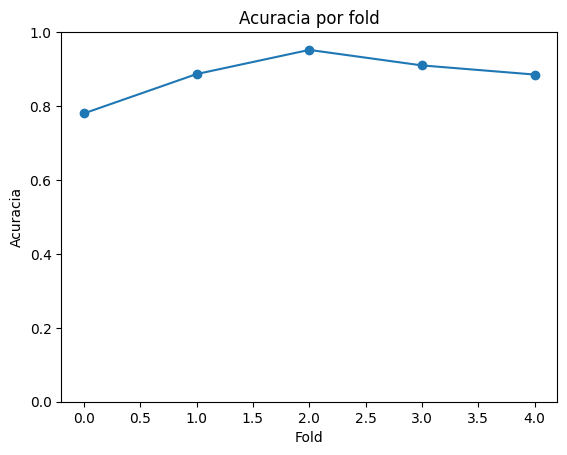

In [11]:
import matplotlib.pyplot as plt

plt.plot(resultados, marker="o")
plt.title("Acuracia por fold")
plt.xlabel("Fold")
plt.ylabel("Acuracia")
plt.ylim(0, 1)
plt.show()

Pode-se observar que a rede parece ter se adaptado bem aos dados, o que é sinal de que esta arquitetura é válida para resolver este problema.